Answering
#### Describing the past. What happened, how stocks moved, how risky they were.

In [ ]:
# install the library
!pip install yfinance

In [ ]:
# pull real data
import yfinance as yf
import pandas as pd

# These are real stock tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Download 3 years of daily closing prices
data = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']

print(data.head())
print(data.shape)

/tmp/ipykernel_646/3444076366.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

Ticker            AAPL       AMZN      GOOGL        MSFT        TSLA
Date                                                                
2023-01-03  122.982712  85.820000  88.389473  233.452820  108.099998
2023-01-04  124.251183  85.139999  87.357986  223.240814  113.639999
2023-01-05  122.933563  83.120003  85.493393  216.624481  110.339996
2023-01-06  127.456787  86.080002  86.624054  219.177460  113.059998
2023-01-09  127.977928  87.360001  87.298477  221.311432  119.769997
(752, 5)


**What's happening:** hitting Yahoo Finance's servers and pulling a full 3 year of real closing prices for 5 companies - the same data professional analysts use.

 Exploring The Real Mess

In [ ]:
# Any missing trading days?
print(data.isnull().sum())

Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64


In [ ]:
# Basic stats on real prices
print(data.describe())

Ticker        AAPL        AMZN       GOOGL        MSFT        TSLA
count   752.000000  752.000000  752.000000  752.000000  752.000000
mean    202.342273  174.584881  163.619381  394.701785  268.253285
std      34.337950   43.718781   49.670776   75.412357   88.567771
min     122.933563   83.120003   85.493393  216.624481  108.099998
25%     175.687035  135.480003  131.329556  330.945076  197.417500
50%     197.476578  182.070000  160.600418  406.346359  248.449997
75%     226.608334  213.615005  179.719746  441.165184  328.492493
max     285.659271  254.000000  323.001190  539.825256  489.880005


In [ ]:
# What does the raw data look like?
print(data.tail(10))

Ticker            AAPL        AMZN       GOOGL        MSFT        TSLA
Date                                                                  
2025-12-17  271.335876  221.270004  296.511261  475.035736  467.260010
2025-12-18  271.685242  226.759995  302.247223  482.877869  483.369995
2025-12-19  273.162506  227.350006  306.943939  484.813446  481.200012
2025-12-22  270.467499  228.429993  309.562073  483.815735  488.730011
2025-12-23  271.854919  232.139999  314.128876  485.741333  485.559998
2025-12-24  273.302216  232.380005  313.869049  486.908630  485.399994
2025-12-26  272.893005  232.520004  313.289459  486.599365  475.190002
2025-12-29  273.252350  232.070007  313.339417  485.990753  459.640015
2025-12-30  272.573547  232.529999  313.629242  486.369904  454.429993
2025-12-31  271.355835  230.820007  312.779816  482.518677  449.720001


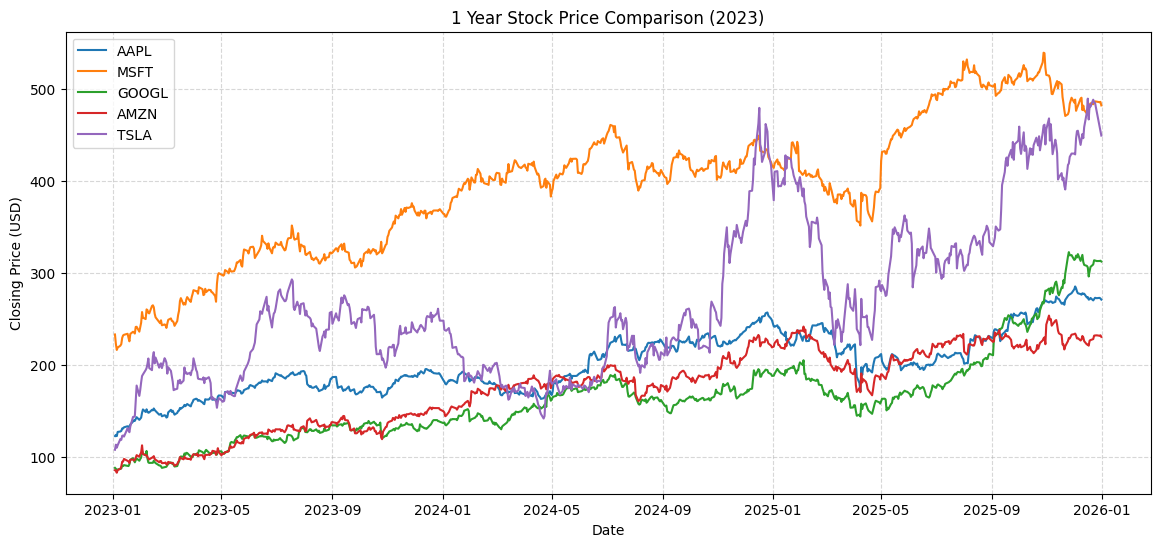

In [ ]:
# Real Financial Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title('1 Year Stock Price Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

The above is a multi-line time series chart - one of the most common charts in investment analysis.

#### One Key Finance Concept:Daily Returns

Stock price alone is misleading. A 3000 Amazon stock isn't "better" than a $170 Apple stock. What matters is how much it grows.

In [ ]:
# Calculating daily percentage returns
returns = data.pct_change().dropna()

print(returns.head())

Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2023-01-04  0.010314 -0.007924 -0.011670 -0.043743  0.051249
2023-01-05 -0.010604 -0.023726 -0.021344 -0.029638 -0.029039
2023-01-06  0.036794  0.035611  0.013225  0.011785  0.024651
2023-01-09  0.004089  0.014870  0.007786  0.009736  0.059349
2023-01-10  0.004457  0.028732  0.004544  0.007617 -0.007681


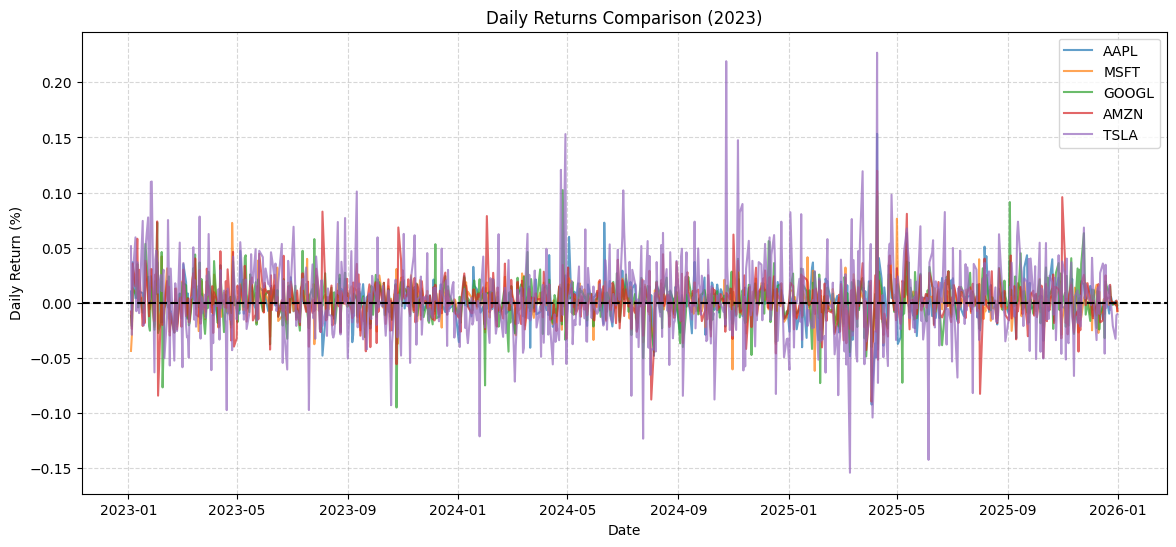

In [ ]:
# Visualizing returns
plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(returns.index, returns[ticker], label=ticker, alpha=0.7)

plt.title('Daily Returns Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

What **pct_change()** does: Converts raw prices into percentage change day-over-day. This is how analysts actually compare stocks fairly - it's the foundation of portfolio analysis.

#### Measuring Volatility With Math
In finance, **volatility = standard deviation of daily returns**. The higher it is, the riskier the stock.

In [ ]:
# Calculate annualized volatility for each stock
volatility = returns.std() * (252 ** 0.5)  # 252 = trading days in a year

print("Annualized Volatility:")
print(volatility.sort_values(ascending=False))

Annualized Volatility:
Ticker
TSLA     0.600591
AMZN     0.319368
GOOGL    0.302746
AAPL     0.256012
MSFT     0.232048
dtype: float64


What's happening:

- std() measures how wildly returns jump around
- We multiply by √252 to scale it to a full year - this is standard practice in finance

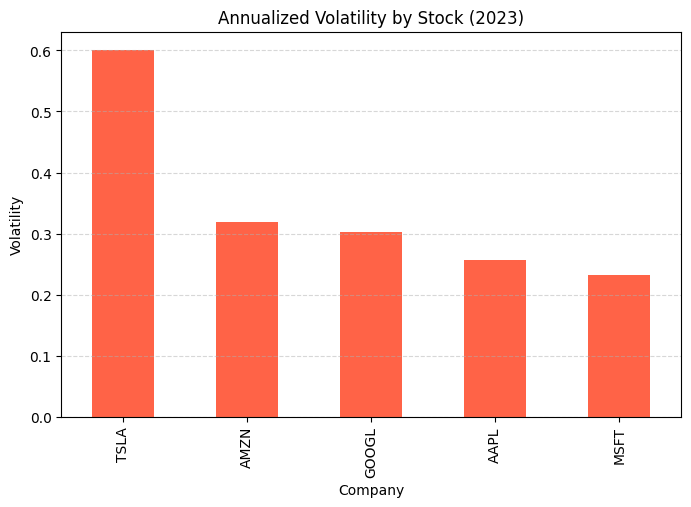

In [ ]:
# Visualizing Volatility
plt.figure(figsize=(8, 5))
volatility.sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title('Annualized Volatility by Stock (2023)')
plt.xlabel('Company')
plt.ylabel('Volatility')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Comparing Risk vs Return
This is the most important chart in portfolio management. Every investment decision lives here.

In [ ]:
# Average annual return
annual_return = returns.mean() * 252

# Build a comparison table
summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Volatility (Risk)': volatility
})

print(summary.sort_values('Annual Return', ascending=False))

        Annual Return  Volatility (Risk)
Ticker                                  
TSLA         0.656810           0.600591
GOOGL        0.470087           0.302746
AMZN         0.382957           0.319368
AAPL         0.298152           0.256012
MSFT         0.270496           0.232048


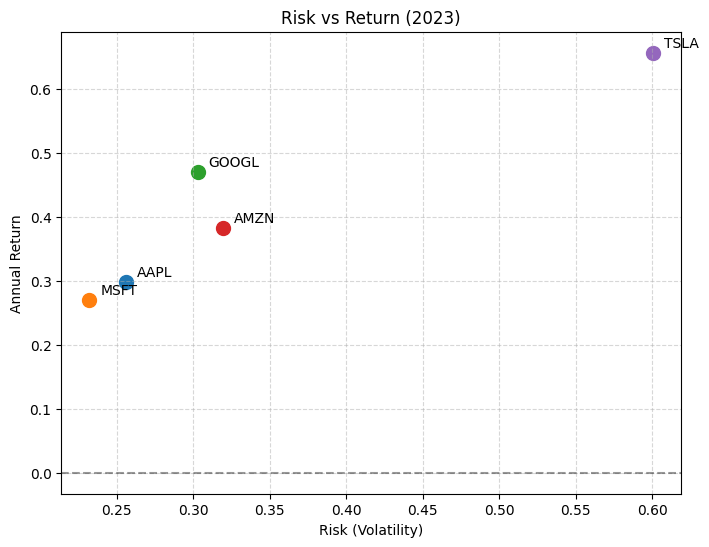

In [ ]:
# Plot Risk vs Return - the core of portfolio theory
plt.figure(figsize=(8, 6))

for ticker in tickers:
    plt.scatter(
        summary.loc[ticker, 'Volatility (Risk)'],
        summary.loc[ticker, 'Annual Return'],
        s=100
    )
    plt.annotate(
        ticker,
        (summary.loc[ticker, 'Volatility (Risk)'],
        summary.loc[ticker, 'Annual Return']),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=10
    )

plt.title('Risk vs Return (2023)')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Annual Return')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4)
plt.grid(linestyle='--', alpha=0.5)
plt.show()

This scatter plot is the foundation of Modern Portfolio Theory - the framework every asset manager and portfolio manager uses. The idea is simple:

- Top left = ideal - high return, low risk
- Bottom right = worst - low return, high risk
- my job as a portfolio manager is to build a mix of assets that pushes your portfolio toward the top left

- Tesla was most volatile
- Tesla had the best return for its risk level
- Tesla landed on top right----and it wa not worth the risk

High return and high risk means Tesla rewards you, but could also hurt you badly in a bad year. That's not ideal for a wealth management portfolio where protecting client money matters as much as growing it.

### The Sharpe Ratio: One Number That Judges Every Stock
In portfolio management, we don't just ask **"did this stock make money?"** We ask **"did it make enough money for the risk it took?"**

That's exactly what the Sharpe Ratio measures:

**Sharpe Ratio = (Return - Risk Free Rate) / Volatility**

The risk free rate is what you'd earn doing nothing risky - like a US government bond. Currently around 5% (0.05).

In [ ]:
risk_free_rate = 0.05

sharpe = (annual_return - risk_free_rate) / volatility

print("Sharpe Ratios:")
print(sharpe.sort_values(ascending=False))

Sharpe Ratios:
Ticker
GOOGL    1.387588
AMZN     1.042552
TSLA     1.010355
AAPL     0.969299
MSFT     0.950219
dtype: float64


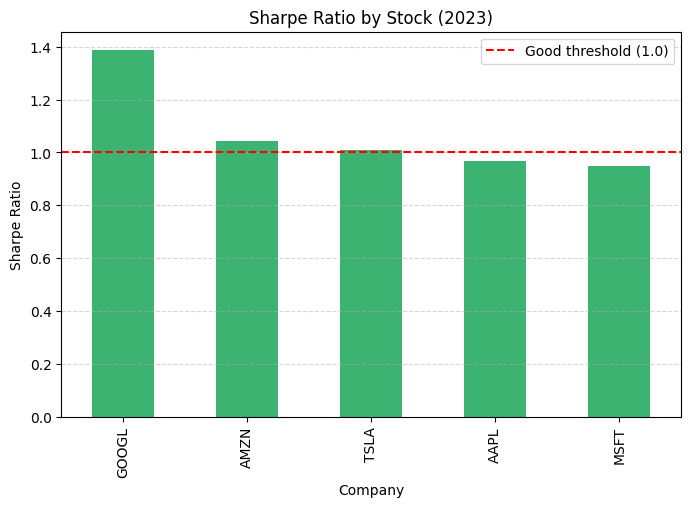

In [ ]:
# Visualizing it
plt.figure(figsize=(8, 5))
sharpe.sort_values(ascending=False).plot(kind='bar', color='mediumseagreen')
plt.title('Sharpe Ratio by Stock (2023)')
plt.xlabel('Company')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=1, color='red', linestyle='--', label='Good threshold (1.0)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

How to read sharpe ratio:

- Above 1.0 = good, earning well for the risk taken
- Below 1.0 = questionable, not enough return for the risk
- Negative = losing money after accounting for risk free rate

## Building a Mini Portfolio

Acting like an actual portfolio manager. I have a client. I need to split $100,000 across these 5 stocks.

In [ ]:
# Defining portfolio weights (must add up to 1.0)
weights = {
    'AAPL': 0.30,
    'MSFT': 0.30,
    'GOOGL': 0.20,
    'AMZN': 0.10,
    'TSLA': 0.10   # Small Tesla allocation - high risk, so we limit exposure
}

weights_series = pd.Series(weights)

# Portfolio return
portfolio_return = (annual_return * weights_series).sum()

# Portfolio volatility (simplified)
portfolio_volatility = (volatility * weights_series).sum()

# Portfolio Sharpe
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Portfolio Annual Return:  {portfolio_return:.2%}")
print(f"Portfolio Volatility:     {portfolio_volatility:.2%}")
print(f"Portfolio Sharpe Ratio:   {portfolio_sharpe:.2f}")

Portfolio Annual Return:  36.86%
Portfolio Volatility:     29.90%
Portfolio Sharpe Ratio:   1.07


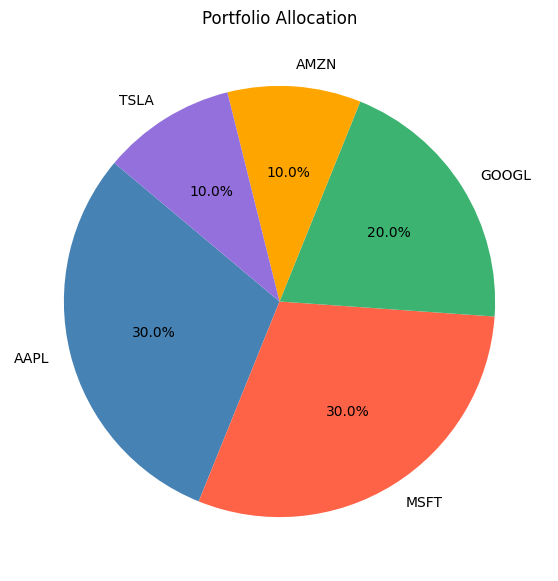

In [ ]:
# Visualizing the allocation
plt.figure(figsize=(7, 7))
plt.pie(
    weights_series,
    labels=weights_series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
plt.title('Portfolio Allocation')
plt.show()

What  I Just did

I just did in code what portfolio managers do in boardrooms:

- Measured each stock's risk and return
- Judged quality using the Sharpe Ratio
- Built a weighted portfolio that limits exposure to risky assets
- Visualized the allocation like a professional

I feel that the allocation is not right....But the rule in data science and finance:

**Never adjust a portfolio based on feeling. Adjust it based on evidence.**

So let's let the data tell us how to fix it.....by interrogating the Weights With Data

In [ ]:
# First let's see exactly what each stock is contributing to the portfolio
# Contribution of each stock to overall return
contribution = annual_return * weights_series

print("Return Contribution per Stock:")
print(contribution.sort_values(ascending=False))

Return Contribution per Stock:
GOOGL    0.094017
AAPL     0.089446
MSFT     0.081149
TSLA     0.065681
AMZN     0.038296
dtype: float64


In [ ]:
# Risk contribution per stock
risk_contribution = volatility * weights_series

print("\nRisk Contribution per Stock:")
print(risk_contribution.sort_values(ascending=False))


Risk Contribution per Stock:
AAPL     0.076804
MSFT     0.069614
GOOGL    0.060549
TSLA     0.060059
AMZN     0.031937
dtype: float64


In [ ]:
# Side by side comparison
comparison = pd.DataFrame({
    'Weight': weights_series,
    'Annual Return': annual_return,
    'Volatility': volatility,
    'Sharpe Ratio': sharpe,
    'Return Contribution': contribution,
    'Risk Contribution': risk_contribution
})

print(comparison.round(3))

       Weight  Annual Return  Volatility  Sharpe Ratio  Return Contribution  \
AAPL      0.3          0.298       0.256         0.969                0.089   
AMZN      0.1          0.383       0.319         1.043                0.038   
GOOGL     0.2          0.470       0.303         1.388                0.094   
MSFT      0.3          0.270       0.232         0.950                0.081   
TSLA      0.1          0.657       0.601         1.010                0.066   

       Risk Contribution  
AAPL               0.077  
AMZN               0.032  
GOOGL              0.061  
MSFT               0.070  
TSLA               0.060  


Let **The Sharpe Ratio** Guide our Weights

The logic is simple - reward stocks with high Sharpe Ratios with more weight.

In [ ]:
# Building smarter weights based on Sharpe Ratio
# Higher Sharpe = more allocation
sharpe_weights = sharpe / sharpe.sum()

print("Sharpe-Based Weights:")
print(sharpe_weights.sort_values(ascending=False).round(3))

Sharpe-Based Weights:
Ticker
GOOGL    0.259
AMZN     0.195
TSLA     0.188
AAPL     0.181
MSFT     0.177
dtype: float64


In [ ]:
# Recalculating portfolio with smarter weights
smart_return = (annual_return * sharpe_weights).sum()
smart_volatility = (volatility * sharpe_weights).sum()
smart_sharpe = (smart_return - risk_free_rate) / smart_volatility

print(f"\nSmart Portfolio Annual Return:  {smart_return:.2%}")
print(f"Smart Portfolio Volatility:     {smart_volatility:.2%}")
print(f"Smart Portfolio Sharpe Ratio:   {smart_sharpe:.2f}")


Smart Portfolio Annual Return:  42.19%
Smart Portfolio Volatility:     34.11%
Smart Portfolio Sharpe Ratio:   1.09


Now lets compare Both Portfolios Head To Head

In [ ]:
# Building comparison table
portfolio_comparison = pd.DataFrame({
    'Our Original Portfolio': [portfolio_return, portfolio_volatility, portfolio_sharpe],
    'Data-Driven Portfolio': [smart_return, smart_volatility, smart_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print(portfolio_comparison.round(3))

               Our Original Portfolio  Data-Driven Portfolio
Annual Return                   0.369                  0.422
Volatility                      0.299                  0.341
Sharpe Ratio                    1.066                  1.090


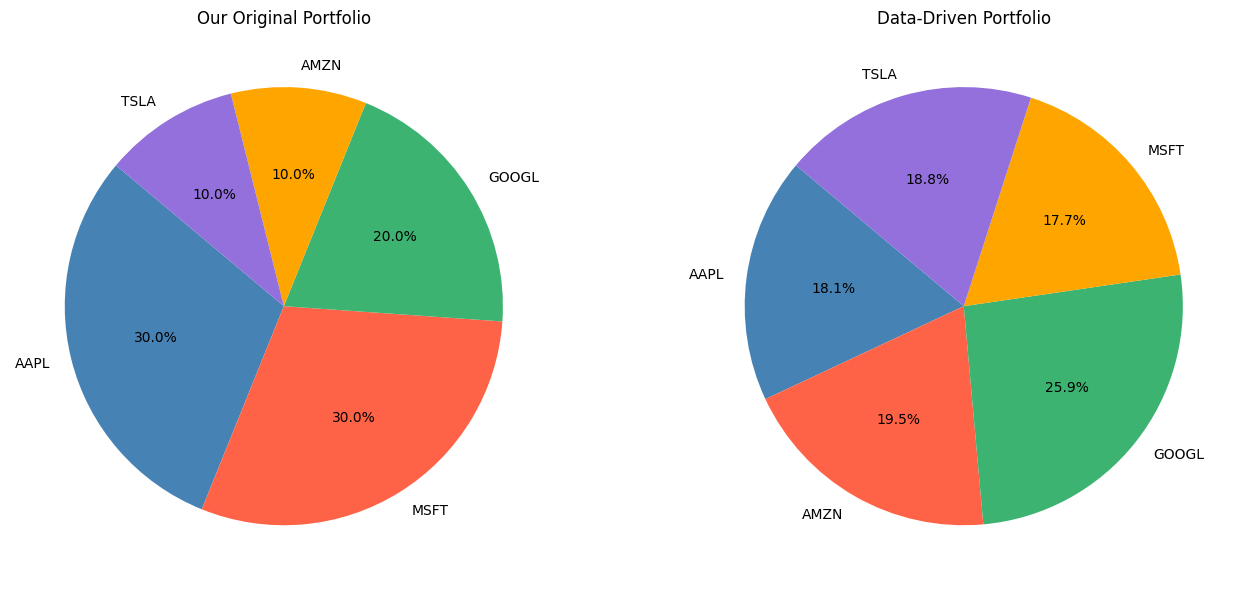

In [ ]:
# Visualizing new allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
axes[0].pie(
    weights_series,
    labels=weights_series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
axes[0].set_title('Our Original Portfolio')

# Smart
axes[1].pie(
    sharpe_weights,
    labels=sharpe_weights.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
axes[1].set_title('Data-Driven Portfolio')

plt.tight_layout()
plt.show()

What we're doing above

This is called **portfolio optimization** - valuable skills in wealth and asset management.

Am not guessing weights anymore. Am deriving them mathematically from evidence.

Real portfolio managers do this exact process,..... with hundreds of assets and more complex models.

- Questions to ask myself

Which stock got the most weight in the data-driven portfolio - and does that make sense given its Sharpe?

**google.....yeah it makes sense since it has the highest sharpe ratio**

How much did Tesla's weight change?

**it went up with a 8.8%**

Did the Sharpe Ratio improve in the smart portfolio vs your original?

**yes it did...because it allocated more weights to stocks with higher sharpe ratio**

####⚠️ Problem
Past performance (is not = to) future results.

Tesla had a great 2023. But in 2022, it crashed over 65% in a single year. If we had used 2022 data, our model would have slashed Tesla's weight to almost zero.

 *the model is only as honest as the time period you feed it.


In [ ]:
# Prove itt with data
# Let's check 2022 and see how dramatically the story changes
# Pulling 2022 data
data_2022 = yf.download(tickers, start='2022-01-01', end='2023-01-01')['Close']
returns_2022 = data_2022.pct_change().dropna()

annual_return_2022 = returns_2022.mean() * 252
volatility_2022 = returns_2022.std() * (252 ** 0.5)
sharpe_2022 = (annual_return_2022 - risk_free_rate) / volatility_2022

print("2022 Sharpe Ratios:")
print(sharpe_2022.sort_values(ascending=False).round(3))

/tmp/ipykernel_646/3078998411.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2022 = yf.download(tickers, start='2022-01-01', end='2023-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

2022 Sharpe Ratios:
Ticker
MSFT    -0.888
AAPL    -0.899
GOOGL   -1.228
AMZN    -1.271
TSLA    -1.561
dtype: float64


In [ ]:
# Comparing Sharpe across both years side by side
sharpe_comparison = pd.DataFrame({
    '2022 Sharpe': sharpe_2022,
    '2023 Sharpe': sharpe
})

print("\nSharpe Ratio: 2022 vs 2023")
print(sharpe_comparison.round(3))


Sharpe Ratio: 2022 vs 2023
        2022 Sharpe  2023 Sharpe
Ticker                          
AAPL         -0.899        0.969
AMZN         -1.271        1.043
GOOGL        -1.228        1.388
MSFT         -0.888        0.950
TSLA         -1.561        1.010


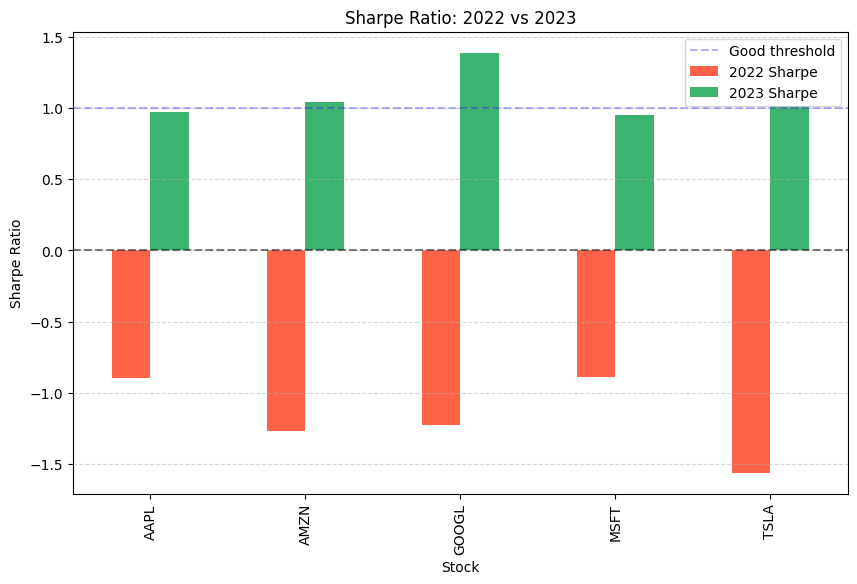

In [ ]:
# Visualizing the difference
sharpe_comparison.plot(kind='bar', figsize=(10, 6), color=['tomato', 'mediumseagreen'])
plt.title('Sharpe Ratio: 2022 vs 2023')
plt.xlabel('Stock')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='blue', linestyle='--', alpha=0.3, label='Good threshold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Build A More Honest Portfolio Using Both Years

A smarter approach - averaging the Sharpe across multiple years so one good or bad year doesn't dominate decision.

In [ ]:
# Averaging Sharpe across 2022 and 2023
avg_sharpe = (sharpe_2022 + sharpe) / 2

print("Average Sharpe (2022-2023):")
print(avg_sharpe.sort_values(ascending=False).round(3))

Average Sharpe (2022-2023):
Ticker
GOOGL    0.080
AAPL     0.035
MSFT     0.031
AMZN    -0.114
TSLA    -0.275
dtype: float64


In [ ]:
# Handling negative Sharpe values before weighting
# can't give negative weight to a stock - so floor at zero
avg_sharpe_clipped = avg_sharpe.clip(lower=0)

# If all are zero or negative, this catches that edge case
if avg_sharpe_clipped.sum() == 0:
    balanced_weights = pd.Series([1/len(tickers)]*len(tickers), index=tickers)
else:
    balanced_weights = avg_sharpe_clipped / avg_sharpe_clipped.sum()

print("\nBalanced Portfolio Weights:")
print(balanced_weights.sort_values(ascending=False).round(3))


Balanced Portfolio Weights:
Ticker
GOOGL    0.546
AAPL     0.242
MSFT     0.212
AMZN     0.000
TSLA     0.000
dtype: float64


In [ ]:
# Final portfolio performance
balanced_return = (annual_return * balanced_weights).sum()
balanced_volatility = (volatility * balanced_weights).sum()
balanced_sharpe = (balanced_return - risk_free_rate) / balanced_volatility

# Full comparison — all three portfolios
final_comparison = pd.DataFrame({
    'Gut Portfolio': [portfolio_return, portfolio_volatility, portfolio_sharpe],
    'Single Year (2023)': [smart_return, smart_volatility, smart_sharpe],
    'Balanced (2yr avg)': [balanced_return, balanced_volatility, balanced_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print("\nFinal Portfolio Comparison:")
print(final_comparison.round(3))


Final Portfolio Comparison:
               Gut Portfolio  Single Year (2023)  Balanced (2yr avg)
Annual Return          0.369               0.422               0.386
Volatility             0.299               0.341               0.276
Sharpe Ratio           1.066               1.090               1.216


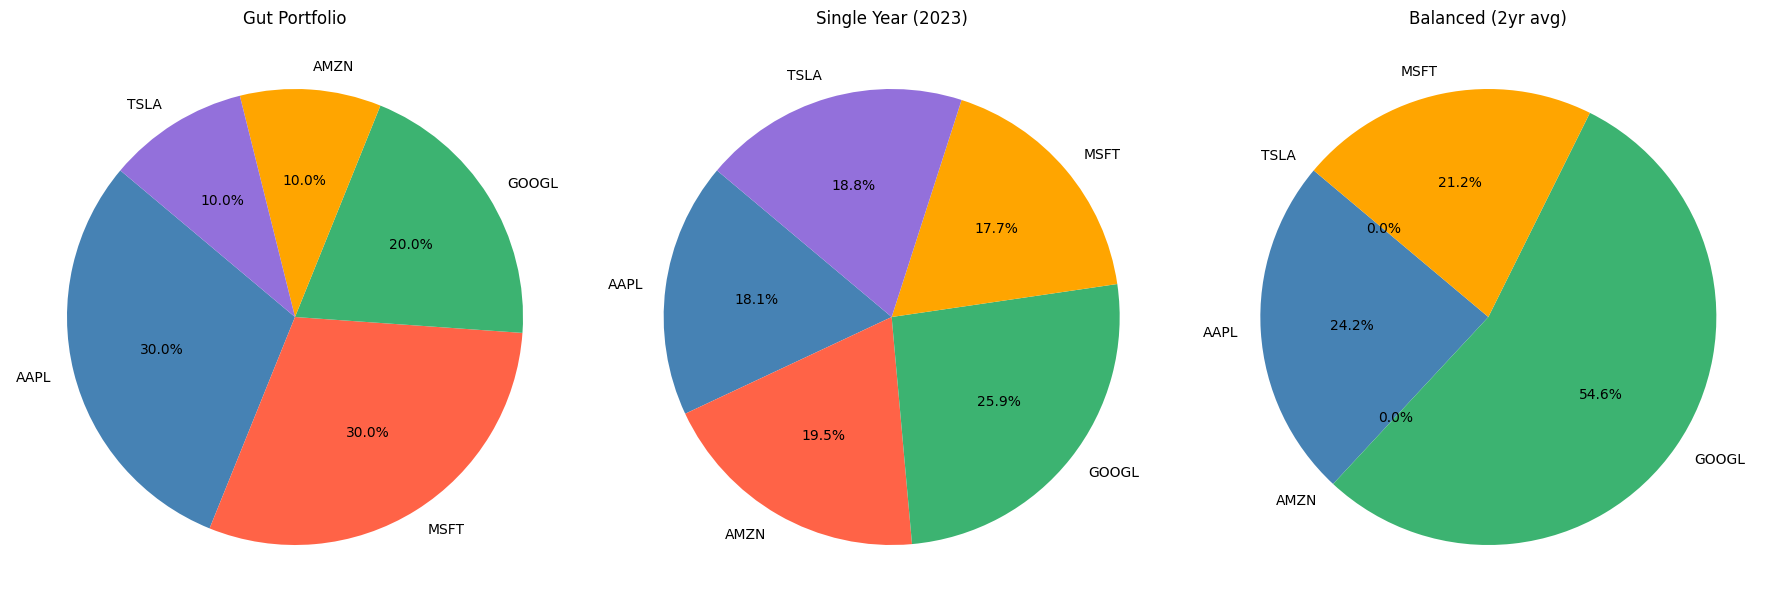

In [ ]:
# Visualizing all three allocations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['steelblue','tomato','mediumseagreen','orange','mediumpurple']

portfolios = [
    (weights_series, 'Gut Portfolio'),
    (sharpe_weights, 'Single Year (2023)'),
    (balanced_weights, 'Balanced (2yr avg)')
]

for ax, (w, title) in zip(axes, portfolios):
    ax.pie(w, labels=w.index, autopct='%1.1f%%', startangle=140, colors=colors)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### What I Just Learned
built three versions of a real portfolio and compared them honestly:


Portfolio vs What it represents

---

- Gut Portfolio -> How beginners
invest - feeling based

---

- Single Year -> Data-driven but overfit to one period

---

- Balanced 2yr -> More robust - accounts for good and bad years

---


🏆 Checkpoint - what i have achieved


---


What I Did   vs   What It's Called Professionally


---


- Cleaned messy company data...*Data wrangling
- Pulled live market prices...*Financial data engineering
- Measured price swings...*Volatility analysis
- Scored stocks fairly...*Sharpe Ratio analysis
- Split money across stocks...*Portfolio allocation
- Tested across multiple years...*Backtesting
- Chose the most honest model...*Risk-adjusted decision making


### Diversification
**Correlation** - why owning Google AND Microsoft might be the same bet.

If Google drops 10% on a bad tech news day, Microsoft probably drops too - because they move together. Smart portfolio manager doesn't just pick strong stocks. They pick stocks that don't move together so when one falls, another holds or rises.
That's called **diversification**

### Measuring how Stocks move together (Correlation)
Will add a stock from a completely different industry to our portfolio. We'll add JPMorgan (JPM) - a bank and Johnson & Johnson (JNJ) - healthcare.

**The idea:** tech stocks tend to fall together. Adding different industries should protect the portfolio.

In [ ]:
# Expand our ticker list
tickers_new = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'JNJ']

# Pulling 4 years of data
data_new = yf.download(tickers_new, start='2022-01-01', end='2026-01-01')['Close']
returns_new = data_new.pct_change().dropna()

print(data_new.head())
print(f"\nShape: {data_new.shape}")

/tmp/ipykernel_646/4066074563.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_new = yf.download(tickers_new, start='2022-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  7 of 7 completed

Ticker            AAPL        AMZN       GOOGL         JNJ         JPM  \
Date                                                                     
2022-01-03  177.939713  170.404495  143.802979  151.770020  144.191589   
2022-01-04  175.681396  167.522003  143.215820  151.363052  149.657822   
2022-01-05  171.008255  164.356995  136.645615  152.371674  146.921799   
2022-01-06  168.153580  163.253998  136.618347  151.849655  148.482681   
2022-01-07  168.319778  162.554001  135.893845  153.902283  149.953873   

Ticker            MSFT        TSLA  
Date                                
2022-01-03  323.160797  399.926666  
2022-01-04  317.619537  383.196655  
2022-01-05  305.426819  362.706665  
2022-01-06  303.013275  354.899994  
2022-01-07  303.167786  342.320007  

Shape: (1003, 7)


In [ ]:
#  Building The Correlation Matrix
# Calculating correlation between all stocks
correlation = returns_new.corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
Ticker  AAPL  AMZN  GOOGL   JNJ   JPM  MSFT  TSLA
Ticker                                           
AAPL    1.00  0.56   0.58  0.15  0.40  0.63  0.51
AMZN    0.56  1.00   0.62  0.01  0.39  0.67  0.47
GOOGL   0.58  0.62   1.00  0.05  0.35  0.63  0.44
JNJ     0.15  0.01   0.05  1.00  0.22  0.05 -0.01
JPM     0.40  0.39   0.35  0.22  1.00  0.36  0.35
MSFT    0.63  0.67   0.63  0.05  0.36  1.00  0.43
TSLA    0.51  0.47   0.44 -0.01  0.35  0.43  1.00


How to read correlation:

Value vs Meaning
- 1.0 --- Move perfectly together0.
- 0 --- No relationship at all
- -1.0 --- Move in opposite directions

A good portfolio wants low or negative correlations between holdings.

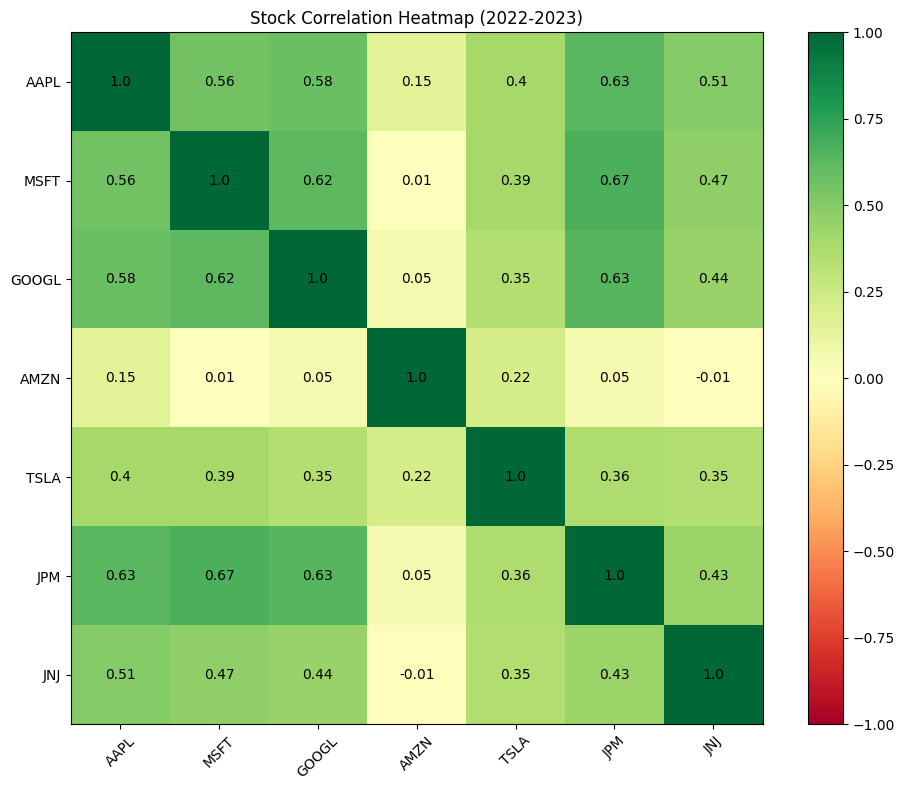

In [ ]:
# Visualizing it as a Heatmap
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap manually
im = ax.imshow(correlation, cmap='RdYlGn', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im)

# Label axes
ax.set_xticks(range(len(tickers_new)))
ax.set_yticks(range(len(tickers_new)))
ax.set_xticklabels(tickers_new, rotation=45)
ax.set_yticklabels(tickers_new)

# Add correlation numbers inside each cell
for i in range(len(tickers_new)):
    for j in range(len(tickers_new)):
        text = ax.text(j, i, round(correlation.iloc[i, j], 2),
                      ha='center', va='center', fontsize=10,
                      color='black')

plt.title('Stock Correlation Heatmap (2022-2023)')
plt.tight_layout()
plt.show()

In [ ]:
# Interpretion of the Heatmap
# Finding the highest correlated pairs (excluding self-correlation of 1.0)
corr_pairs = correlation.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self correlation
corr_pairs = corr_pairs.drop_duplicates()

print("Most Correlated Pairs (move TOGETHER - bad for diversification):")
print(corr_pairs.sort_values(ascending=False).head(5).round(3))

print("\nLeast Correlated Pairs (move INDEPENDENTLY - good for diversification):")
print(corr_pairs.sort_values(ascending=True).head(5).round(3))

Most Correlated Pairs (move TOGETHER - bad for diversification):
Ticker  Ticker
AMZN    MSFT      0.668
GOOGL   MSFT      0.633
AAPL    MSFT      0.628
AMZN    GOOGL     0.625
AAPL    GOOGL     0.585
dtype: float64

Least Correlated Pairs (move INDEPENDENTLY - good for diversification):
Ticker  Ticker
JNJ     TSLA     -0.008
AMZN    JNJ       0.013
JNJ     MSFT      0.055
GOOGL   JNJ       0.055
AAPL    JNJ       0.154
dtype: float64


#### Prove Diversification Works

In [ ]:
# Compare: all-tech portfolio vs diversified portfolio
tech_weights = pd.Series({
    'AAPL': 0.25, 'MSFT': 0.25, 'GOOGL': 0.25,
    'AMZN': 0.25, 'TSLA': 0.00, 'JPM': 0.00, 'JNJ': 0.00
})

diversified_weights = pd.Series({
    'AAPL': 0.20, 'MSFT': 0.20, 'GOOGL': 0.15,
    'AMZN': 0.10, 'TSLA': 0.05, 'JPM': 0.20, 'JNJ': 0.10
})

# Calculate returns and volatility for both
annual_return_new = returns_new.mean() * 252
volatility_new = returns_new.std() * (252 ** 0.5)

tech_return = (annual_return_new * tech_weights).sum()
tech_vol = (volatility_new * tech_weights).sum()
tech_sharpe = (tech_return - 0.05) / tech_vol

div_return = (annual_return_new * diversified_weights).sum()
div_vol = (volatility_new * diversified_weights).sum()
div_sharpe = (div_return - 0.05) / div_vol

# Final comparison
diversification_comparison = pd.DataFrame({
    'All-Tech Portfolio': [tech_return, tech_vol, tech_sharpe],
    'Diversified Portfolio': [div_return, div_vol, div_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print(diversification_comparison.round(3))

               All-Tech Portfolio  Diversified Portfolio
Annual Return               0.169                  0.175
Volatility                  0.313                  0.295
Sharpe Ratio                0.381                  0.423


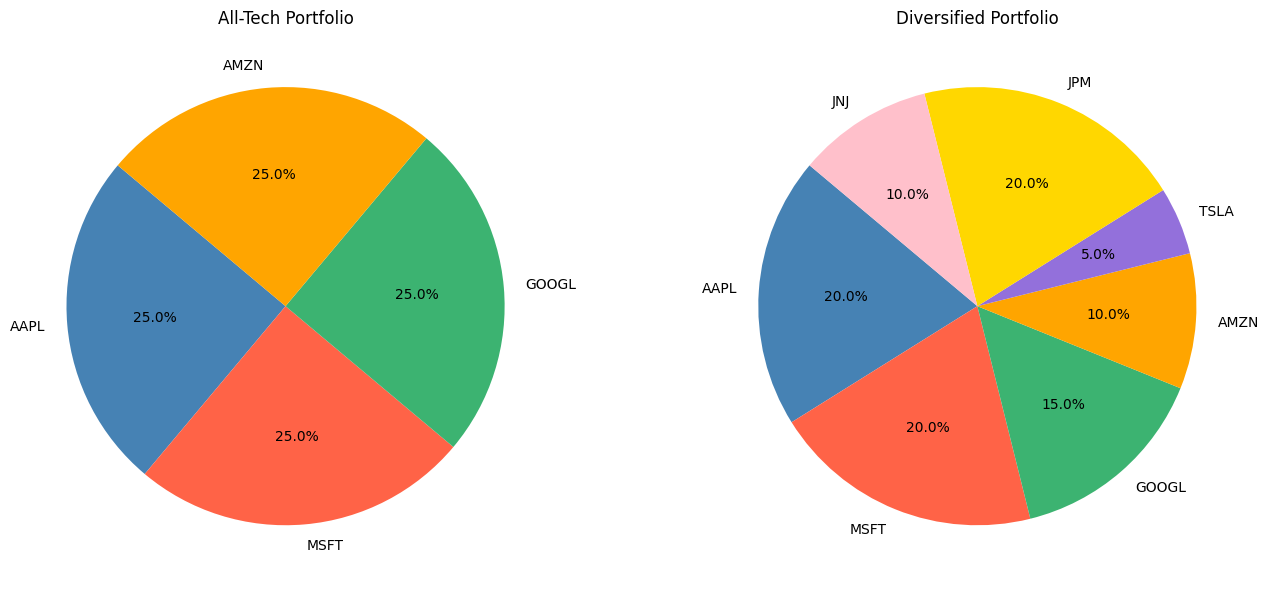

In [ ]:
# Visualizing both allocations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['steelblue','tomato','mediumseagreen','orange','mediumpurple','gold','pink']

for ax, (weights, title) in zip(axes, [
    (tech_weights[tech_weights > 0], 'All-Tech Portfolio'),
    (diversified_weights[diversified_weights > 0], 'Diversified Portfolio')
]):
    ax.pie(weights, labels=weights.index, autopct='%1.1f%%',
           startangle=140, colors=colors)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### Questions
- Which two stocks are most correlated - and does that surprise you?

amazon and microsoft.....no,beacause they all belong to the tech industry

- Which pair is least correlated - what does that tell you?

Johnson & Johnson and Tesla......stocks from different industry tend to perform/move a bit different

- Did diversification improve the Sharpe Ratio vs the all-tech portfolio?

yes....it improved it from 0.381 to 0.423

- Based on the heatmap - which stock looks like the best diversifier?

Johnson & Johnson

🧠 Proved with Real Data that;

Insight vs Professional Term


---


- Tech stocks move together....*Sector correlation
- JNJ & TSLA move differently....*Low cross-sector correlation
- Diversification improved Sharpe....*Risk-adjusted optimization
- JNJ is the best diversifier....*Defensive asset

JNJ being a defensive asset is a real finance concept. Healthcare stocks hold their value during market downturns because people still need medicine regardless of the economy. That's exactly why wealth managers add them to client portfolios.

###🏆 Full Checkpoint  What I've Built so far

Project: Portfolio Analysis Engine


---


✅ Data cleaning & wrangling

✅ Live market data extraction

✅ Volatility analysis

✅ Sharpe Ratio scoring

✅ Portfolio allocation

✅ Backtesting across multiple years

✅ Correlation analysis

✅ Heatmap visualization

✅ Diversification proof



---



#  **Prediction territory**

Building a model that answers one of the most important questions in investment management:

**"Given how this stock has been behaving - where is it likely going?"**

This is called **forecasting** - where data science and finance become genuinely powerful together

I'll use a technique called **Moving Averages** first - the same signals professional traders watch every single day on Bloomberg terminals.
Then build toward a simple machine learning model that predicts price direction.



#### Moving Averages: What Traders Watch Every Day

A moving average smooths out the noise of daily price swings and reveals the underlying trend.
Two are used everywhere in professional trading:

- 50-day MA - short term trend
- 200-day MA - long term trend

When they cross - that's a trading signal.

In [ ]:
# Using Google since it was our strongest performer
googl = data_new['GOOGL'].copy()

# Calculating moving averages
googl_ma = pd.DataFrame()
googl_ma['Price'] = googl
googl_ma['MA50'] = googl.rolling(window=50).mean()
googl_ma['MA200'] = googl.rolling(window=200).mean()

print(googl_ma.tail(10))

                 Price        MA50       MA200
Date                                          
2025-12-17  296.511261  284.703123  210.424929
2025-12-18  302.247223  285.862304  211.075047
2025-12-19  306.943939  287.177137  211.751982
2025-12-22  309.562073  288.643397  212.434493
2025-12-23  314.128876  290.049599  213.178653
2025-12-24  313.869049  291.424641  213.930632
2025-12-26  313.289459  292.676641  214.664417
2025-12-29  313.339417  293.921053  215.420126
2025-12-30  313.629242  295.134510  216.163681
2025-12-31  312.779816  296.266068  216.908969


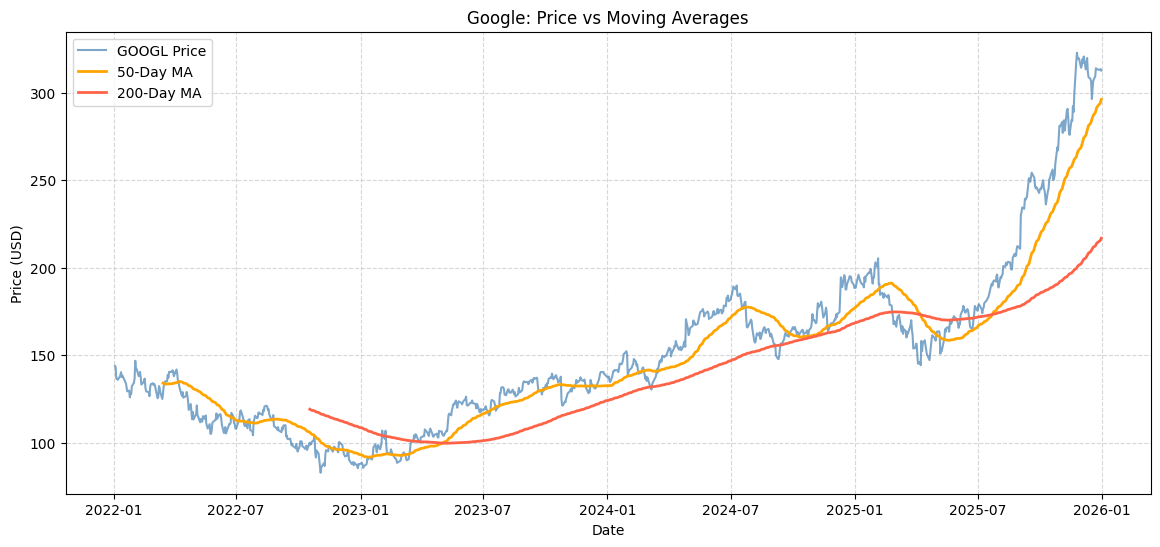

In [ ]:
# Visualizing The Signals
plt.figure(figsize=(14, 6))

plt.plot(googl_ma['Price'], label='GOOGL Price', color='steelblue', alpha=0.7)
plt.plot(googl_ma['MA50'], label='50-Day MA', color='orange', linewidth=2)
plt.plot(googl_ma['MA200'], label='200-Day MA', color='tomato', linewidth=2)

plt.title('Google: Price vs Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

#### The Golden Cross & Death Cross
These are real terms used on Bloomberg and CNBC every day.

- Golden Cross - 50-day MA crosses above 200-day MA → bullish signal → price likely rising
- Death Cross - 50-day MA crosses below 200-day MA → bearish signal → price likely falling

In [ ]:
# Detect crossover signals
googl_ma['Signal'] = 0

# Golden Cross — MA50 crosses above MA200
googl_ma.loc[
    (googl_ma['MA50'] > googl_ma['MA200']) &
    (googl_ma['MA50'].shift(1) <= googl_ma['MA200'].shift(1)),
    'Signal'
] = 1

# Death Cross — MA50 crosses below MA200
googl_ma.loc[
    (googl_ma['MA50'] < googl_ma['MA200']) &
    (googl_ma['MA50'].shift(1) >= googl_ma['MA200'].shift(1)),
    'Signal'
] = -1

# Show only the signal dates
signals = googl_ma[googl_ma['Signal'] != 0]
print("Crossover Signals Detected:")
print(signals[['Price', 'MA50', 'MA200', 'Signal']])

Crossover Signals Detected:
                 Price        MA50       MA200  Signal
Date                                                  
2023-05-03  104.545937   99.843199   99.734050       1
2025-04-08  144.199982  172.725480  173.099414      -1
2025-07-23  189.802155  173.499862  173.287223       1


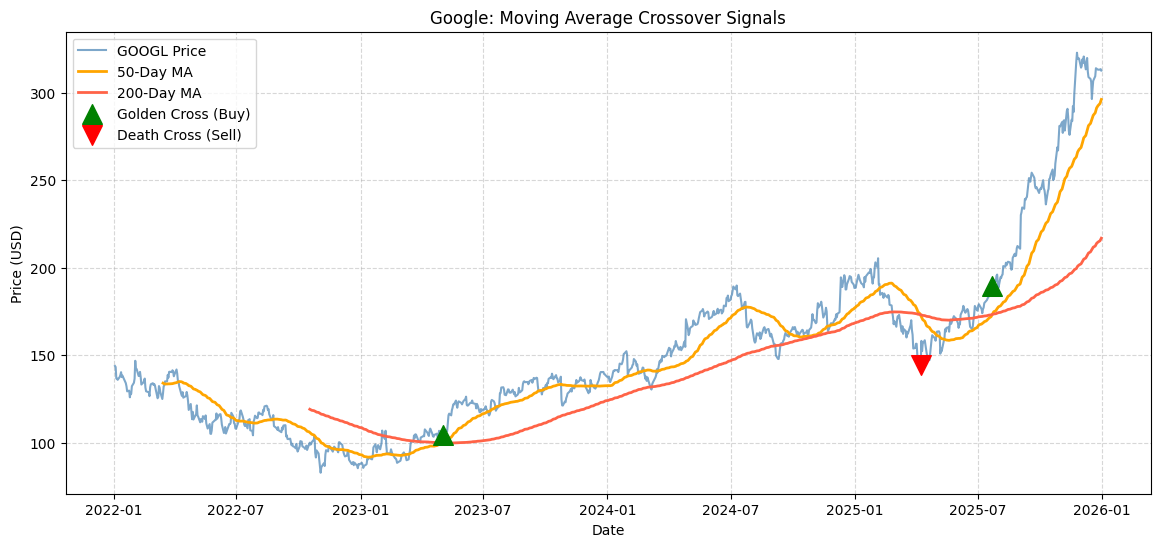

In [ ]:
# Plot with signals marked
plt.figure(figsize=(14, 6))

plt.plot(googl_ma['Price'], label='GOOGL Price', color='steelblue', alpha=0.7)
plt.plot(googl_ma['MA50'], label='50-Day MA', color='orange', linewidth=2)
plt.plot(googl_ma['MA200'], label='200-Day MA', color='tomato', linewidth=2)

# Mark Golden Cross
golden = googl_ma[googl_ma['Signal'] == 1]
plt.scatter(golden.index, golden['Price'], marker='^', color='green',
            s=200, zorder=5, label='Golden Cross (Buy)')

# Mark Death Cross
death = googl_ma[googl_ma['Signal'] == -1]
plt.scatter(death.index, death['Price'], marker='v', color='red',
            s=200, zorder=5, label='Death Cross (Sell)')

plt.title('Google: Moving Average Crossover Signals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

Testing if The Signals Actually Work

This is backtesting a trading strategy - did following these signals make money?

In [ ]:
# Strategy: Buy on Golden Cross, Sell on Death Cross
googl_ma['Daily_Return'] = googl_ma['Price'].pct_change()

# Hold position based on MA50 vs MA200
googl_ma['Position'] = 0
googl_ma.loc[googl_ma['MA50'] > googl_ma['MA200'], 'Position'] = 1  # long
googl_ma.loc[googl_ma['MA50'] < googl_ma['MA200'], 'Position'] = -1  # out

# Strategy return vs just holding
googl_ma['Strategy_Return'] = googl_ma['Daily_Return'] * googl_ma['Position'].shift(1)

# Cumulative returns
googl_ma['Buy_Hold'] = (1 + googl_ma['Daily_Return']).cumprod()
googl_ma['MA_Strategy'] = (1 + googl_ma['Strategy_Return']).cumprod()

# Final result
final_buyhold = googl_ma['Buy_Hold'].iloc[-1]
final_strategy = googl_ma['MA_Strategy'].iloc[-1]

print(f"Buy & Hold Return:      {(final_buyhold - 1):.2%}")
print(f"MA Strategy Return:     {(final_strategy - 1):.2%}")
print(f"Strategy Edge:          {(final_strategy - final_buyhold):.2%}")

Buy & Hold Return:      117.51%
MA Strategy Return:     46.82%
Strategy Edge:          -70.69%


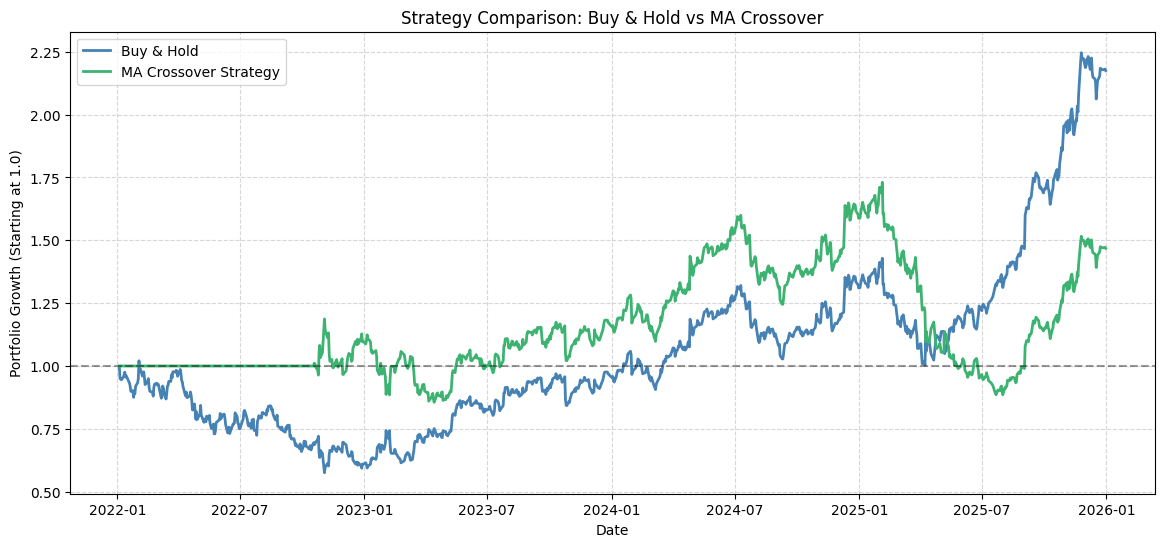

In [ ]:
# Visualizing both strategies
plt.figure(figsize=(14, 6))

plt.plot(googl_ma['Buy_Hold'], label='Buy & Hold', color='steelblue', linewidth=2)
plt.plot(googl_ma['MA_Strategy'], label='MA Crossover Strategy', color='mediumseagreen', linewidth=2)

plt.title('Strategy Comparison: Buy & Hold vs MA Crossover')
plt.xlabel('Date')
plt.ylabel('Portfolio Growth (Starting at 1.0)')
plt.legend()
plt.axhline(y=1, color='black', linestyle='--', alpha=0.4)
plt.grid(linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Checking the date range of my data
print(f"Data starts: {data_new.index[0].date()}")
print(f"Data ends:   {data_new.index[-1].date()}")

Data starts: 2022-01-03
Data ends:   2025-12-31


Note
- Did the MA strategy beat buy & hold — or did simply holding Google win?

no, it did not.....simply holding won

- What does that result tell you about trading signals in general?

trading signals can make you some returns .....however holding will make you more returns in the long run


 Discovery:

**"Time in the market beats timing the market"**

- Passive → buy the market, hold forever, low fees
- Active → use signals, pick stocks, charge higher fees

# Machine Learning Model
Moving averages are rule-based. They follow fixed logic you program manually.

Machine learning is different - the model learns the rules from the data itself.

Am going to build a model that looks at historical price patterns and predicts whether Google's price will go up or down tomorrow.

This is called a **binary classification model** - and it's used in hedge funds worldwide.

#### Building Features the ML Model

In machine learning, features are the inputs the model learns from. We need to engineer them from price data.

'll use price-derived features - patterns we can calculate directly from what we already have

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Pull fresh Google data
googl = yf.download('GOOGL', start='2022-01-01', end='2025-12-31')['Close'].squeeze()
df_ml = pd.DataFrame()

# Feature 1: Daily Return
df_ml['Return'] = googl.pct_change()

# Feature 2: 5-day momentum (short term trend)
df_ml['Momentum_5'] = googl.pct_change(5)

# Feature 3: 20-day momentum (medium term trend)
df_ml['Momentum_20'] = googl.pct_change(20)

# Feature 4: Volatility over last 10 days
df_ml['Volatility_10'] = df_ml['Return'].rolling(10).std()

# Feature 5: Distance from 50-day MA (is price above or below trend?)
df_ml['MA50'] = googl.rolling(50).mean()
df_ml['Distance_MA50'] = (googl - df_ml['MA50']) / df_ml['MA50']

# Feature 6: Distance from 200-day MA
df_ml['MA200'] = googl.rolling(200).mean()
df_ml['Distance_MA200'] = (googl - df_ml['MA200']) / df_ml['MA200']

# Drop MA columns — model doesn't need them directly
df_ml = df_ml.drop(columns=['MA50', 'MA200'])

print(df_ml.tail(10))

/tmp/ipykernel_646/576078904.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  googl = yf.download('GOOGL', start='2022-01-01', end='2025-12-31')['Close'].squeeze()
[*********************100%***********************]  1 of 1 completed

              Return  Momentum_5  Momentum_20  Volatility_10  Distance_MA50  \
Date                                                                          
2025-12-16 -0.005353   -0.033146     0.076312       0.013766       0.079924   
2025-12-17 -0.032130   -0.073358     0.044442       0.015445       0.041475   
2025-12-18  0.019345   -0.031911     0.033632       0.017597       0.057318   
2025-12-19  0.015539   -0.006887     0.061879       0.018051       0.068831   
2025-12-22  0.008530    0.005061     0.034448       0.017166       0.072472   
2025-12-23  0.014752    0.025378    -0.012632       0.017520       0.083018   
2025-12-24 -0.000827    0.058540    -0.028273       0.017123       0.077016   
2025-12-26 -0.001847    0.036534    -0.019487       0.015210       0.070429   
2025-12-29  0.000159    0.020836    -0.020035       0.014763       0.066067   
2025-12-30  0.000925    0.013138    -0.002651       0.014665       0.062665   

            Distance_MA200  
Date                  

Creating The Target Variable

The model needs to know what it's predicting.

We're asking:

**"Will the price be higher tomorrow than today?"**

In [ ]:
# Target: 1 = price goes up tomorrow, 0 = price goes down
df_ml['Target'] = (googl.shift(-1) > googl).astype(int)

# Drop rows with missing values (from rolling calculations)
df_ml = df_ml.dropna()

print(f"\nTotal trading days available: {len(df_ml)}")
print(f"\nUp days:   {df_ml['Target'].sum()} ({df_ml['Target'].mean():.1%})")
print(f"Down days: {(df_ml['Target']==0).sum()} ({(1-df_ml['Target'].mean()):.1%})")


Total trading days available: 803

Up days:   441 (54.9%)
Down days: 362 (45.1%)


This balance between up and down days matters - if 90% of days are up days, a lazy model could just always predict "up" and be 90% accurate without learning anything real.

In [ ]:
#  Split Data Into Training and Testing
from sklearn.model_selection import train_test_split

features = ['Return', 'Momentum_5', 'Momentum_20', 'Volatility_10',
            'Distance_MA50', 'Distance_MA200']

X = df_ml[features]
y = df_ml['Target']

# 80% train, 20% test — never train and test on same data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False keeps time order intact
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 642
Testing samples:  161


Why **shuffle=False** matters: Stock data is time-ordered. If you shuffle randomly, your model trains on future data to predict the past - that's called **data leakage** and it's one of the most common mistakes in financial ML. It produces fake accuracy.

In [ ]:
# Training the ML Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Build the model
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees voting together
    max_depth=4,         # keep shallow to avoid overfitting
    random_state=42
)

# Train it
model.fit(X_train, y_train)

# Test it
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 57.14%

Detailed Report:
              precision    recall  f1-score   support

           0       0.50      0.75      0.60        68
           1       0.71      0.44      0.54        93

    accuracy                           0.57       161
   macro avg       0.60      0.60      0.57       161
weighted avg       0.62      0.57      0.57       161



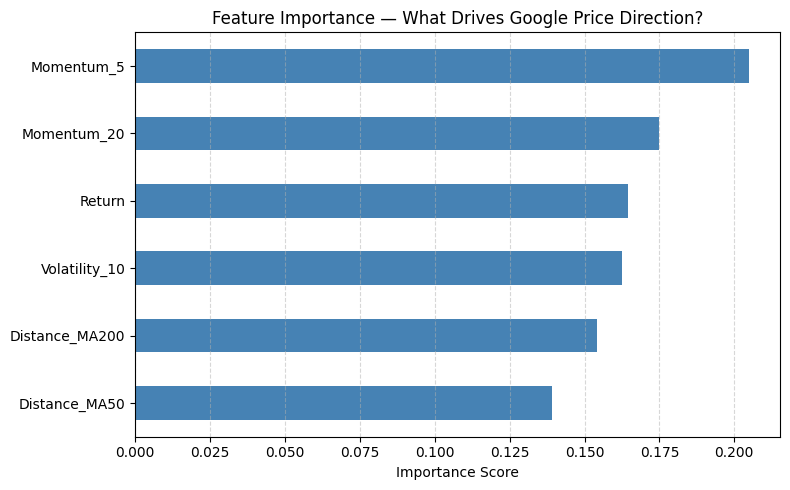

In [ ]:
# Feature importance — what did the model find most useful?
importance = pd.Series(model.feature_importances_, index=features)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What Drives Google Price Direction?')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

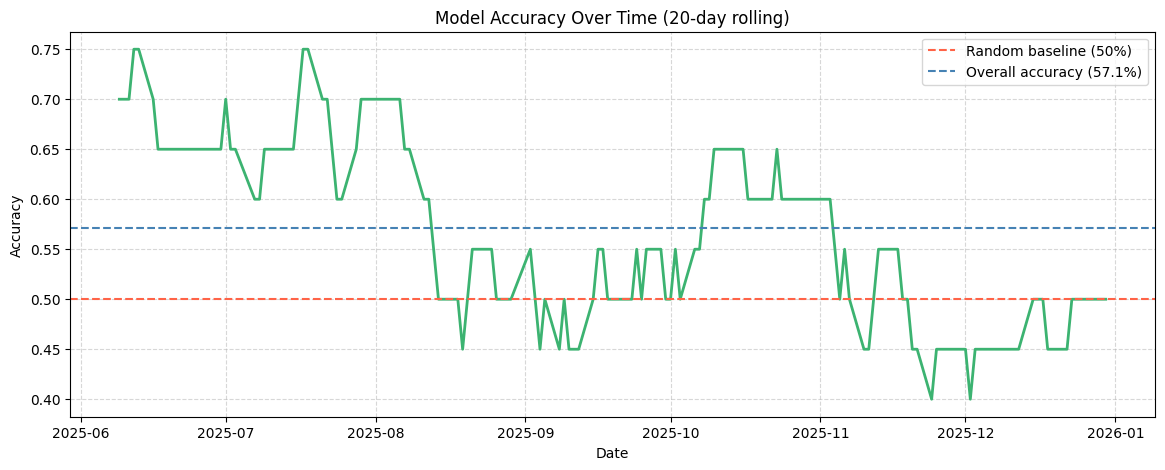

In [ ]:
# Visualizing Predictions vs Reality
# Compare predicted vs actual on test set
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
}, index=y_test.index)

# Cumulative accuracy over time
results['Correct'] = (results['Actual'] == results['Predicted']).astype(int)
results['Rolling_Accuracy'] = results['Correct'].rolling(20).mean()

plt.figure(figsize=(14, 5))
plt.plot(results['Rolling_Accuracy'], color='mediumseagreen', linewidth=2)
plt.axhline(y=0.5, color='tomato', linestyle='--', label='Random baseline (50%)')
plt.axhline(y=accuracy, color='steelblue', linestyle='--', label=f'Overall accuracy ({accuracy:.1%})')
plt.title('Model Accuracy Over Time (20-day rolling)')
plt.xlabel('Date')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

Measuring Real Financial Performance the Model

In [ ]:
# Get actual Google prices for test period
googl_test = googl[y_test.index]

# Calculate daily returns for test period
test_returns = googl_test.pct_change().dropna()

# Align predictions with returns
results_financial = pd.DataFrame({
    'Actual_Return': test_returns,
    'Predicted': predictions[1:]  # shift by 1 to align
}, index=test_returns.index)

# Strategy: invest when model predicts up, stay out when predicts down
results_financial['Strategy_Return'] = (
    results_financial['Actual_Return'] *
    results_financial['Predicted']
)

# Cumulative growth of $10,000
results_financial['Buy_Hold_Growth'] = (
    10000 * (1 + results_financial['Actual_Return']).cumprod()
)
results_financial['ML_Strategy_Growth'] = (
    10000 * (1 + results_financial['Strategy_Return']).cumprod()
)

# Final values
final_bh = results_financial['Buy_Hold_Growth'].iloc[-1]
final_ml = results_financial['ML_Strategy_Growth'].iloc[-1]

print(f"Starting Capital:        $10,000")
print(f"Buy & Hold Final Value:  ${final_bh:,.2f}")
print(f"ML Strategy Final Value: ${final_ml:,.2f}")
print(f"Difference:              ${final_ml - final_bh:,.2f}")

Starting Capital:        $10,000
Buy & Hold Final Value:  $19,860.96
ML Strategy Final Value: $11,532.52
Difference:              $-8,328.44


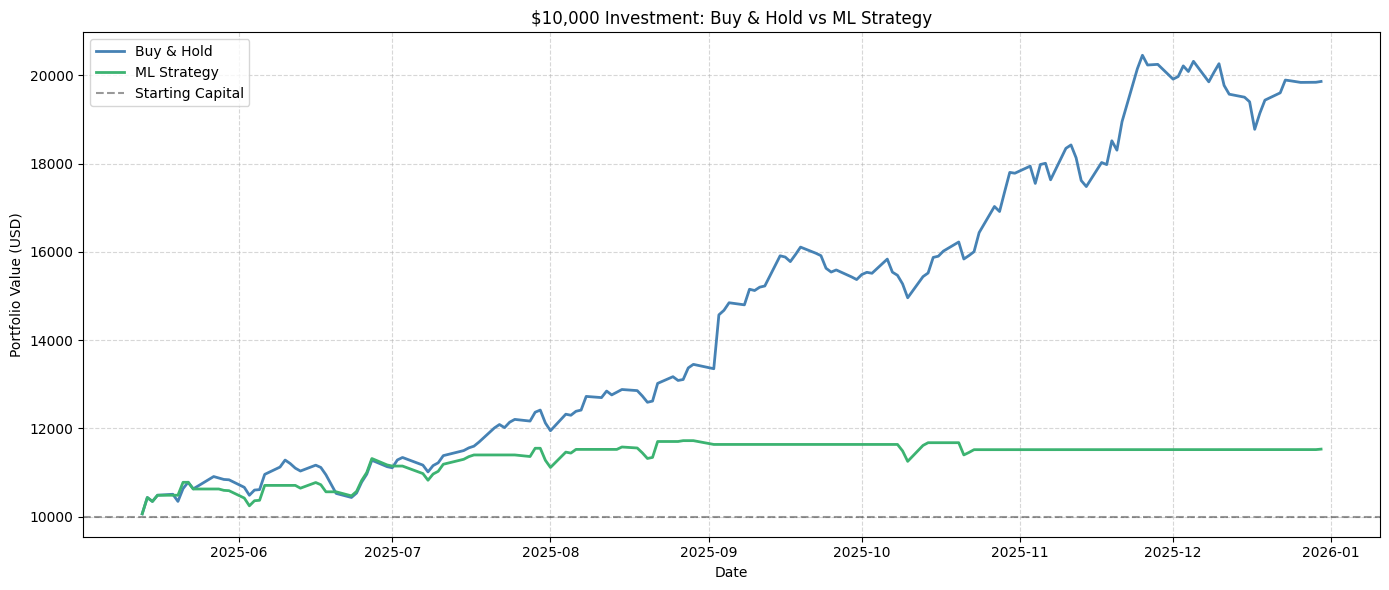

In [ ]:
# Visualizing $10,000 growth
plt.figure(figsize=(14, 6))

plt.plot(results_financial['Buy_Hold_Growth'],
         label='Buy & Hold', color='steelblue', linewidth=2)
plt.plot(results_financial['ML_Strategy_Growth'],
         label='ML Strategy', color='mediumseagreen', linewidth=2)

plt.axhline(y=10000, color='black', linestyle='--', alpha=0.4, label='Starting Capital')
plt.title('$10,000 Investment: Buy & Hold vs ML Strategy')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Measuring The Model's Risk Too

In [ ]:
# Sharpe Ratio of ML strategy vs Buy & Hold
ml_sharpe = (
    results_financial['Strategy_Return'].mean() * 252 - 0.05
) / (results_financial['Strategy_Return'].std() * (252 ** 0.5))

bh_sharpe = (
    results_financial['Actual_Return'].mean() * 252 - 0.05
) / (results_financial['Actual_Return'].std() * (252 ** 0.5))

# Max Drawdown — biggest peak to trough loss
def max_drawdown(growth_series):
    peak = growth_series.cummax()
    drawdown = (growth_series - peak) / peak
    return drawdown.min()

ml_drawdown = max_drawdown(results_financial['ML_Strategy_Growth'])
bh_drawdown = max_drawdown(results_financial['Buy_Hold_Growth'])

# Full comparison
financial_comparison = pd.DataFrame({
    'Buy & Hold': [final_bh, bh_sharpe, bh_drawdown],
    'ML Strategy': [final_ml, ml_sharpe, ml_drawdown]
}, index=['Final Value ($10k start)', 'Sharpe Ratio', 'Max Drawdown'])

print(financial_comparison.round(3))

                          Buy & Hold  ML Strategy
Final Value ($10k start)   19860.958    11532.516
Sharpe Ratio                   3.841        1.279
Max Drawdown                  -0.082       -0.049


A smaller maximum drawdown (MDD) is generally considered better bcoz it indicates less risk and a higher likelihood of recovery. For wealth managers, a smaller MDD is crucial as it reflects a more stable and resilient investment portfolio. It shows that the portfolio can withstand significant losses before retuning to a new high, which is essential for maintaining investor confidence and trust. additionly, a smaller MDD can be a benchmark fro risk adjusted performance, helping to compare the portfolio's risk levels with benchmarks and other investment options

Visualizing Max Drawdown

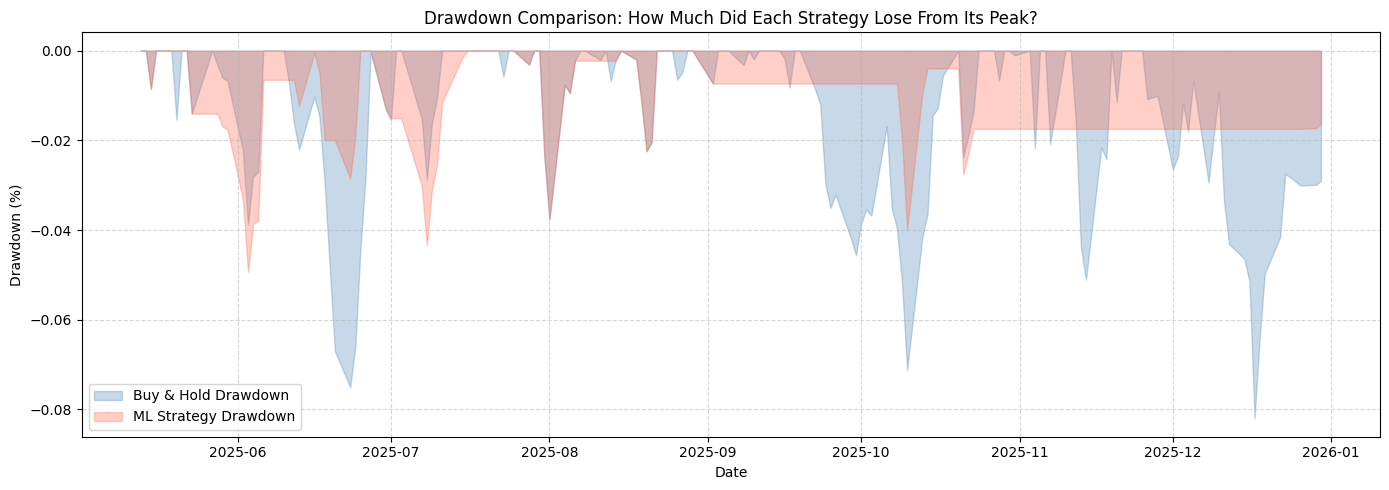

In [ ]:
# Show drawdown over time for both strategies
bh_peak = results_financial['Buy_Hold_Growth'].cummax()
ml_peak = results_financial['ML_Strategy_Growth'].cummax()

bh_dd = (results_financial['Buy_Hold_Growth'] - bh_peak) / bh_peak
ml_dd = (results_financial['ML_Strategy_Growth'] - ml_peak) / ml_peak

plt.figure(figsize=(14, 5))
plt.fill_between(bh_dd.index, bh_dd, 0, alpha=0.3, color='steelblue', label='Buy & Hold Drawdown')
plt.fill_between(ml_dd.index, ml_dd, 0, alpha=0.3, color='tomato', label='ML Strategy Drawdown')
plt.title('Drawdown Comparison: How Much Did Each Strategy Lose From Its Peak?')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Which strategy grew $10,000 more - ML or Buy & Hold?

buy & hold

- Which had a better Sharpe Ratio?

buy & hold...Sharpe ratio of 3.841 vs the 1.279 of ML

- Which had a smaller Max Drawdown - and why does that matter to a wealth manager?

ML....it indicates less risk and higher likelihood of recovery

- What is your overall conclusion — is this ML model useful or not?

its useful since it will help choose a strategy with less risk of the clients portfolio



The ML model made less money, scored worse on risk-adjusted returns, but had a smaller drawdown.

So the real question is:

**Is protecting against drawdown worth sacrificing a Sharpe Ratio of 3.841 down to 1.279?**

The answer depends entirely on **who your client is**.

#### **The Most Important Lesson In Wealth Management**
There is no single best strategy. There is only the right strategy for the right client.

#### Client Type | What They Need | Best Approach
---

Young aggressive investor | Maximum growth | Buy & Hold

---

Retiree living off portfolio | Capital protection | Lower drawdown strategy

---

Institutional fund | Risk-adjusted returns | High Sharpe Ratio

---

Nervous first-time investor | Peace of mind | Minimal volatility

---


- This is why wealth managers spend **more time understanding clients** than analyzing stocks. The numbers only answer half the question.


🏆 Full Project Checkpoint
Everything I've built from scratch:

---

#### PORTFOLIO ANALYSIS ENGINE - COMPLETE

---

✅ Data cleaning & wrangling                 

---

✅ Live market data extraction               

---

✅ Volatility analysis

---

✅ Sharpe Ratio scoring                     

---

✅ Portfolio allocation                 

---

✅ Backtesting across multiple years         

---

✅ Correlation analysis                    

---

✅ Heatmap visualization

---

✅ Diversification proof

---

✅ Moving average signals

---

✅ Golden & Death Cross detection

---

✅ Random Forest ML model

---

✅ Feature importance analysis

---

✅ Financial performance evaluation

---

✅ Max Drawdown analysis

---

✅ Client-context decision making

---

I started as a complete beginner. I just built what a junior quant analyst would be proud to show in an interview.

# Smarter ML Model
- Better features + news sentiment
- Goal: Push accuracy above 60%


**Why the model only reached 57%?**

because we did not have more or enough information and insight of the stock.( The model was essentially trying to predict human behavior using only price history)

#### Building A Smarter Model
We'll add three new information layers:


```
# This is formatted as code
Current Model          Smarter Model
─────────────          ─────────────
Price patterns    →    Price patterns
                  +    Volume behavior
                  +    Relative Strength (RSI)
                  +    Market context (S&P 500)
```

Each one adds real information the model was blind to before

#### Adding Volume As A Feature
- Volume tells you **conviction**. A price rise on high volume means many investors are confident. A price rise on low volume is weak - few people believe it.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pull Google data WITH volume this time
googl_full = yf.download('GOOGL', start='2022-01-01', end='2025-12-31')

# Extract price and volume
price = googl_full['Close'].squeeze()
volume = googl_full['Volume'].squeeze()

df_smart = pd.DataFrame()

# Previous features
df_smart['Return'] = price.pct_change()
df_smart['Momentum_5'] = price.pct_change(5)
df_smart['Momentum_20'] = price.pct_change(20)
df_smart['Volatility_10'] = df_smart['Return'].rolling(10).std()

ma50 = price.rolling(50).mean()
ma200 = price.rolling(200).mean()
df_smart['Distance_MA50'] = (price - ma50) / ma50
df_smart['Distance_MA200'] = (price - ma200) / ma200

# NEW: Volume features
df_smart['Volume_Change'] = volume.pct_change()  # is volume growing?
df_smart['Volume_MA20'] = volume.rolling(20).mean()
df_smart['Volume_Ratio'] = volume / df_smart['Volume_MA20']  # above/below average volume?

print("Volume features added:")
print(df_smart[['Return', 'Volume_Change', 'Volume_Ratio']].tail(5))

/tmp/ipykernel_646/1875192993.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  googl_full = yf.download('GOOGL', start='2022-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed

Volume features added:
              Return  Volume_Change  Volume_Ratio
Date                                             
2025-12-23  0.014752      -0.035990      0.661908
2025-12-24 -0.000827      -0.603692      0.292119
2025-12-26 -0.001847       0.079387      0.334917
2025-12-29  0.000159       0.800330      0.608947
2025-12-30  0.000925      -0.114205      0.560089


#### Adding RSI (Relative Strength Index)
RSI is one of the most widely used indicators in professional trading. It measures whether a stock is overbought (likely to fall) or oversold (likely to rise).

- RSI above 70 → overbought → potential sell signal
- RSI below 30 → oversold → potential buy signal

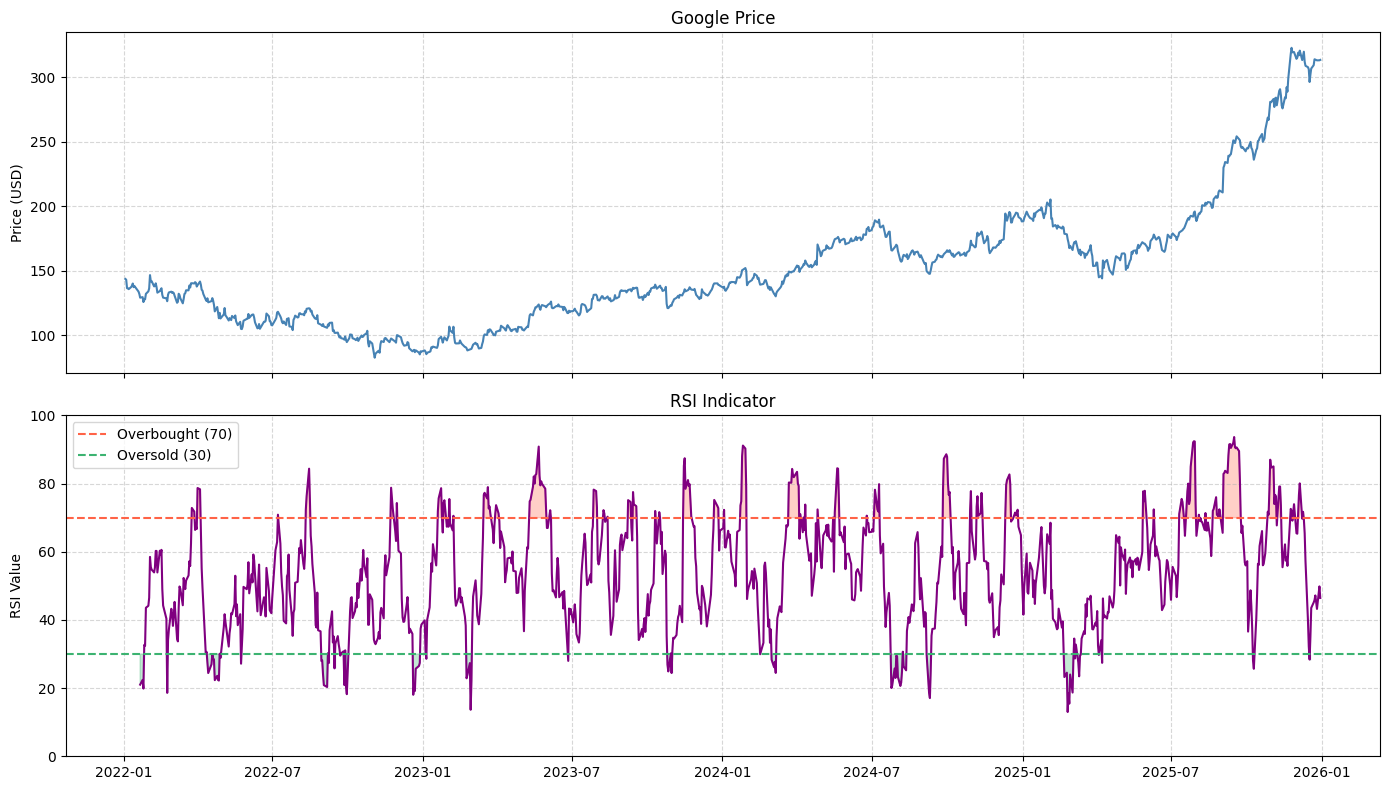

In [ ]:
# Calculate RSI manually so you understand it
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_smart['RSI'] = calculate_rsi(price)

# Visualize RSI
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(price, color='steelblue', linewidth=1.5)
ax1.set_title('Google Price')
ax1.set_ylabel('Price (USD)')
ax1.grid(linestyle='--', alpha=0.5)

ax2.plot(df_smart['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='tomato', linestyle='--', label='Overbought (70)')
ax2.axhline(y=30, color='mediumseagreen', linestyle='--', label='Oversold (30)')
ax2.fill_between(df_smart.index, df_smart['RSI'], 70,
                  where=(df_smart['RSI'] >= 70), alpha=0.3, color='tomato')
ax2.fill_between(df_smart.index, df_smart['RSI'], 30,
                  where=(df_smart['RSI'] <= 30), alpha=0.3, color='mediumseagreen')
ax2.set_title('RSI Indicator')
ax2.set_ylabel('RSI Value')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Adding Market Context (S&P 500)
Google doesn't trade in isolation. When the whole market falls, Google falls with it. Adding S&P 500 behavior gives the model market awareness.

In [ ]:
# Pull S&P 500 data for same period
sp500 = yf.download('^GSPC', start='2022-01-01', end='2025-12-31')['Close'].squeeze()

# S&P 500 features
df_smart['SP500_Return'] = sp500.pct_change()
df_smart['SP500_Momentum_5'] = sp500.pct_change(5)

# Relative strength — is Google outperforming the market?
df_smart['Relative_Strength'] = (
    df_smart['Return'] - df_smart['SP500_Return']
)

print("Market context features added:")
print(df_smart[['Return', 'SP500_Return', 'Relative_Strength']].tail(5))

/tmp/ipykernel_646/2134291918.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start='2022-01-01', end='2025-12-31')['Close'].squeeze()
[*********************100%***********************]  1 of 1 completed

Market context features added:
              Return  SP500_Return  Relative_Strength
Date                                                 
2025-12-23  0.014752      0.004550           0.010202
2025-12-24 -0.000827      0.003221          -0.004049
2025-12-26 -0.001847     -0.000304          -0.001542
2025-12-29  0.000159     -0.003492           0.003652
2025-12-30  0.000925     -0.001376           0.002301


#### Training The Smarter Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Target variable
df_smart['Target'] = (price.shift(-1) > price).astype(int)
df_smart = df_smart.dropna()

# All features including new ones
smart_features = [
    'Return', 'Momentum_5', 'Momentum_20', 'Volatility_10',
    'Distance_MA50', 'Distance_MA200',
    'Volume_Change', 'Volume_Ratio',
    'RSI',
    'SP500_Return', 'SP500_Momentum_5', 'Relative_Strength'
]

X_smart = df_smart[smart_features]
y_smart = df_smart['Target']

# Train/test split — keeping time order
X_train, X_test, y_train, y_test = train_test_split(
    X_smart, y_smart, test_size=0.2, shuffle=False
)

# Train
smart_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
smart_model.fit(X_train, y_train)
smart_predictions = smart_model.predict(X_test)
smart_accuracy = accuracy_score(y_test, smart_predictions)

print(f"Original Model Accuracy: 57.14%")
print(f"Smart Model Accuracy:    {smart_accuracy:.2%}")
print(f"Improvement:             {smart_accuracy - 0.5714:.2%}")

Original Model Accuracy: 57.14%
Smart Model Accuracy:    54.04%
Improvement:             -3.10%


#### Comparing Feature Importance

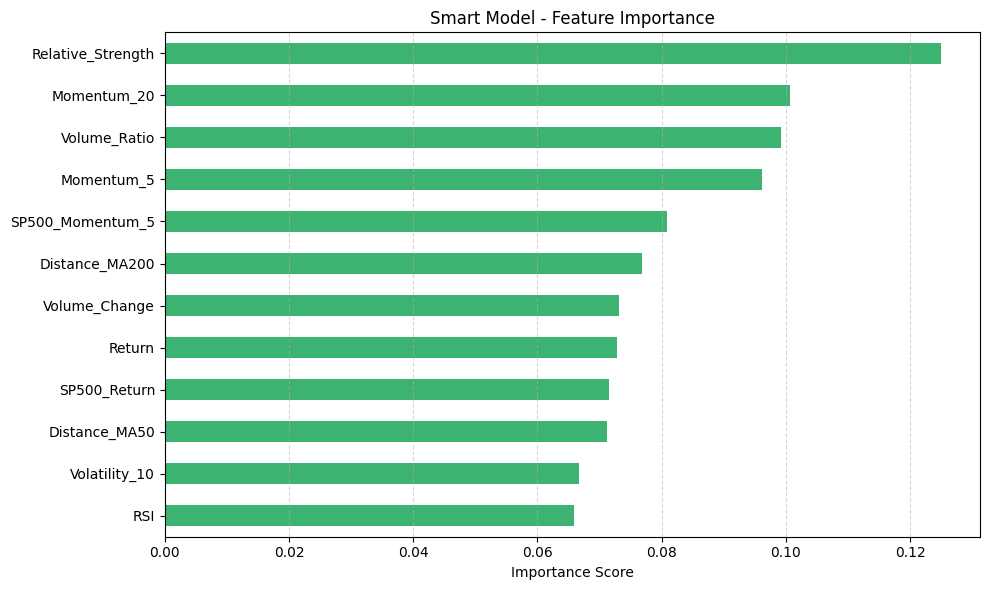

In [ ]:
importance_smart = pd.Series(
    smart_model.feature_importances_,
    index=smart_features
)

plt.figure(figsize=(10, 6))
importance_smart.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Smart Model - Feature Importance')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Financial Performance of Smart Model

In [ ]:
# Test period prices
price_test = price[y_test.index]
test_returns = price_test.pct_change().dropna()

smart_results = pd.DataFrame({
    'Actual_Return': test_returns,
    'Predicted': smart_predictions[1:]
}, index=test_returns.index)

smart_results['Strategy_Return'] = (
    smart_results['Actual_Return'] *
    smart_results['Predicted']
)

# Growth of $10,000
smart_results['Buy_Hold_Growth'] = (
    10000 * (1 + smart_results['Actual_Return']).cumprod()
)
smart_results['Smart_ML_Growth'] = (
    10000 * (1 + smart_results['Strategy_Return']).cumprod()
)

final_bh = smart_results['Buy_Hold_Growth'].iloc[-1]
final_smart = smart_results['Smart_ML_Growth'].iloc[-1]

print(f"Starting Capital:          $10,000")
print(f"Buy & Hold Final Value:    ${final_bh:,.2f}")
print(f"Smart ML Final Value:      ${final_smart:,.2f}")

Starting Capital:          $10,000
Buy & Hold Final Value:    $19,860.96
Smart ML Final Value:      $11,414.52


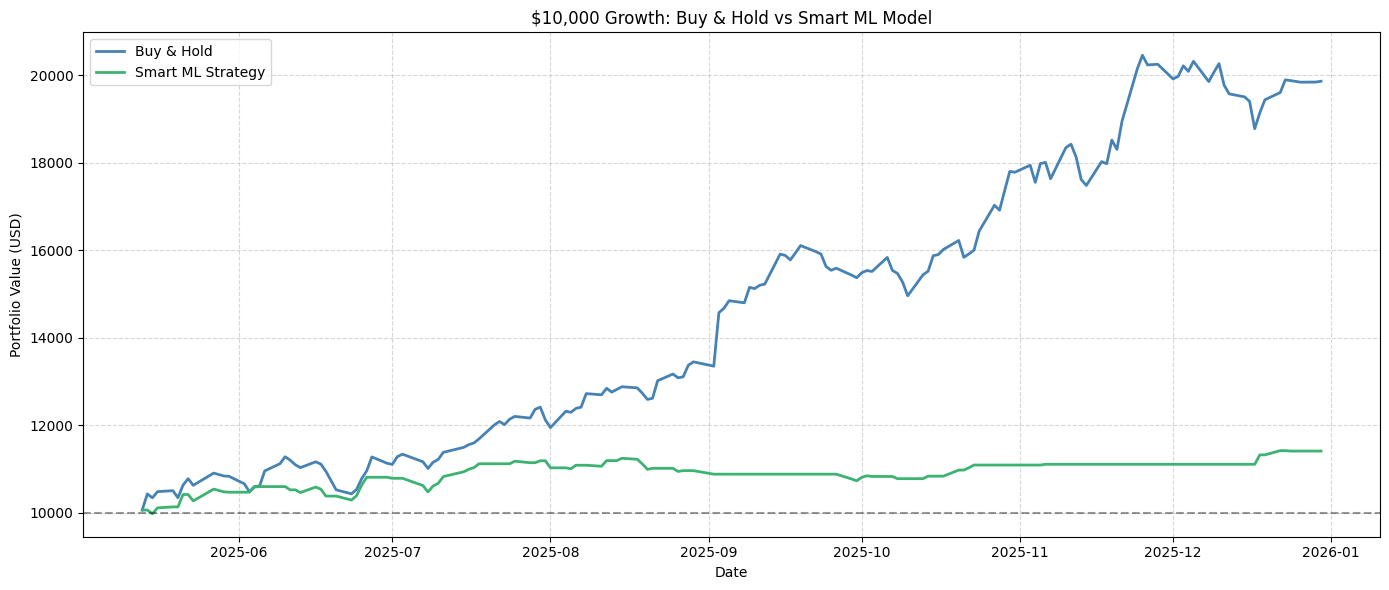

In [ ]:
# Final chart
plt.figure(figsize=(14, 6))
plt.plot(smart_results['Buy_Hold_Growth'],
         label='Buy & Hold', color='steelblue', linewidth=2)
plt.plot(smart_results['Smart_ML_Growth'],
         label='Smart ML Strategy', color='mediumseagreen', linewidth=2)
plt.axhline(y=10000, color='black', linestyle='--', alpha=0.4)
plt.title('$10,000 Growth: Buy & Hold vs Smart ML Model')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Did accuracy improve — by how much?

No.....the accuracy dropped from 57.14% to 54.04%
- Which new feature did the model find most valuable?

most valuable feature was Relative_Strength
- Did the smart model beat buy & hold financially this time?

no , it didn't beat buy & hold
- Looking at the RSI chart - can you spot any moments where Google was oversold and then recovered?

yes

#### Why Accuracy Dropped — The Real Reason
Adding more features doesn't automatically make a model smarter. Sometimes it makes it more confused.

This is called the **Curse of Dimensionality** - when you add too many features, the model starts finding patterns in noise rather than signal. It overfits the training data and performs worse on new data.

Think of it this way:

Giving someone 3 clear clues to solve a mystery is better than giving them 50 clues - half of which are irrelevant and misleading.

#### Fix It With Feature Selection
Instead of using all 12 features, I keep only the ones that actually matter. Relative Strength was the most important - so i build a lean, focused model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use only top features based on importance
lean_features = [
    'Relative_Strength',  # most important
    'RSI',                # overbought/oversold signal
    'Momentum_5',         # short term trend
    'Volume_Ratio',       # conviction behind moves
    'Volatility_10'       # market nervousness
]

X_lean = df_smart[lean_features]
y_lean = df_smart['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X_lean, y_lean, test_size=0.2, shuffle=False
)

lean_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

lean_model.fit(X_train, y_train)
lean_predictions = lean_model.predict(X_test)
lean_accuracy = accuracy_score(y_test, lean_predictions)

print(f"Original Model:  57.14%")
print(f"Smart Model:     54.04%")
print(f"Lean Model:      {lean_accuracy:.2%}")

Original Model:  57.14%
Smart Model:     54.04%
Lean Model:      59.01%


#### Cross Validation (Testing More Honestly)
Train/test split tests the model once. That's not enough - might have gotten lucky or unlucky with that particular split.

**Cross validation** tests the model 5 times on different slices of data and averages the result. Much more honest.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# TimeSeriesSplit respects time order — critical for financial data
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    lean_model, X_lean, y_lean,
    cv=tscv, scoring='accuracy'
)

print("Cross Validation Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.2%}")

print(f"\nAverage Accuracy: {cv_scores.mean():.2%}")
print(f"Std Deviation:    {cv_scores.std():.2%}")

Cross Validation Results:
  Fold 1: 57.14%
  Fold 2: 48.12%
  Fold 3: 62.41%
  Fold 4: 49.62%
  Fold 5: 57.14%

Average Accuracy: 54.89%
Std Deviation:    5.30%


The **standard deviation** tells how **consistent** the model is. High std = model behaves very differently depending on the time period. That's a **red flag** for real deployment.

Visualizing Model Consistency

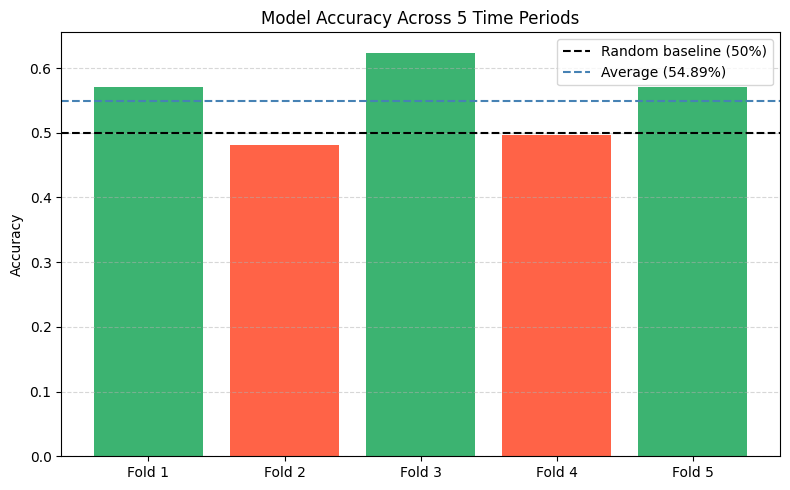

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    [f'Fold {i}' for i in range(1, 6)],
    cv_scores,
    color=['mediumseagreen' if s > 0.5 else 'tomato' for s in cv_scores]
)
plt.axhline(y=0.5, color='black', linestyle='--', label='Random baseline (50%)')
plt.axhline(y=cv_scores.mean(), color='steelblue',
            linestyle='--', label=f'Average ({cv_scores.mean():.2%})')
plt.title('Model Accuracy Across 5 Time Periods')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The Honest Reality Check

In [ ]:
# Comparing all three models cleanly
model_comparison = pd.DataFrame({
    'Accuracy': [0.5714, 0.5404, lean_accuracy, cv_scores.mean()],
    'Features Used': [6, 12, 5, 5],
    'Test Method': [
        'Single split',
        'Single split',
        'Single split',
        'Cross validation'
    ]
}, index=[
    'Original Model',
    'Smart Model (12 features)',
    'Lean Model (5 features)',
    'Lean Model (CV average)'
])

print(model_comparison.round(3))

                           Accuracy  Features Used       Test Method
Original Model                0.571              6      Single split
Smart Model (12 features)     0.540             12      Single split
Lean Model (5 features)       0.590              5      Single split
Lean Model (CV average)       0.549              5  Cross validation


- Did the lean model recover accuracy above 57%?

Lean Model (5 features)   Single split at 59%
Lean Model (CV average)  (5 features)  Cross validation at 54.7%
- What does the cross validation average tell you?

0.547              5  Cross validation.....cross validation gives a more honest
- Which fold performed best and which worst - and what might explain the difference?

Best - Lean Model (5 features)   Single split at 59%.....worst - Smart Model (12 features)  Single split at 54%
- Based on everything so far - what do you think the ceiling of a price-only ML model is in finance?

no...Exceeding this ceiling typically requires incorporating additional data sources (fundamentals, macro indicators, sentiment) beyond pure price history


The **Efficient Market Hypothesis**  the idea that price data alone is already reflected in the market, so you can't consistently beat it using only price patterns.

####🏆 Module 1 Complete
what proved across this entire module:

Experiment vs Lesson

---

Added 12 features → accuracy dropped | More data ≠ better model

---

Lean 5 features → accuracy recovered | Quality beats quantity

---

Single split 59% vs CV 54.7%One test can lie — always cross validate

---

Price-only ceiling ~55-59% | Real alpha requires richer data

### Module 2 - Client Portfolio Dashboard
analytical pieces:

Volatility ✅

Sharpe Ratio ✅

Correlation ✅

Drawdown ✅

ML predictions ✅

### Export All Portfolio Data From Colab
Each one saves a clean CSV file.

In [ ]:
# Stock Prices
# Save 2 years of daily prices
data_new.to_csv('stock_prices.csv')
print("✓ stock_prices.csv saved")

✓ stock_prices.csv saved


In [ ]:
# Daily Returns
# Save daily returns
returns_new.to_csv('daily_returns.csv')
print("✓ daily_returns.csv saved")

✓ daily_returns.csv saved


In [ ]:
# Portfolio Summary Table
# Build and save the summary table
annual_return_new = returns_new.mean() * 252
volatility_new = returns_new.std() * (252 ** 0.5)
sharpe_new = (annual_return_new - 0.05) / volatility_new

portfolio_summary = pd.DataFrame({
    'Ticker': tickers_new,
    'Annual_Return': annual_return_new.values,
    'Volatility': volatility_new.values,
    'Sharpe_Ratio': sharpe_new.values,
    'Weight': [0.20, 0.20, 0.15, 0.10, 0.05, 0.20, 0.10]
})

portfolio_summary['Return_Contribution'] = (
    portfolio_summary['Annual_Return'] * portfolio_summary['Weight']
)
portfolio_summary['Risk_Contribution'] = (
    portfolio_summary['Volatility'] * portfolio_summary['Weight']
)

# Round for cleanliness
portfolio_summary = portfolio_summary.round(4)
portfolio_summary.to_csv('portfolio_summary.csv', index=False)
print("✓ portfolio_summary.csv saved")
print(portfolio_summary)

✓ portfolio_summary.csv saved
  Ticker  Annual_Return  Volatility  Sharpe_Ratio  Weight  \
0   AAPL         0.1466      0.2852        0.3385    0.20   
1   MSFT         0.1460      0.3738        0.2569    0.20   
2  GOOGL         0.2487      0.3265        0.6086    0.15   
3   AMZN         0.0915      0.1725        0.2407    0.10   
4   TSLA         0.2309      0.2495        0.7253    0.05   
5    JPM         0.1366      0.2678        0.3233    0.20   
6    JNJ         0.2196      0.6183        0.2743    0.10   

   Return_Contribution  Risk_Contribution  
0               0.0293             0.0570  
1               0.0292             0.0748  
2               0.0373             0.0490  
3               0.0092             0.0173  
4               0.0115             0.0125  
5               0.0273             0.0536  
6               0.0220             0.0618  


In [ ]:
# Correlation Matrix
# Save correlation matrix
correlation_new = returns_new.corr().round(4)
correlation_new.to_csv('correlation_matrix.csv')
print("✓ correlation_matrix.csv saved")

✓ correlation_matrix.csv saved


In [ ]:
# Cumulative Returns (for growth chart)
# Cumulative growth of $10,000
cumulative = (1 + returns_new).cumprod() * 10000
cumulative = cumulative.round(2)
cumulative.to_csv('cumulative_growth.csv')
print("✓ cumulative_growth.csv saved")

✓ cumulative_growth.csv saved


In [ ]:
# Download All Files From Colab
# downloads all 5 files to Windows PC automatically:
from google.colab import files

files.download('stock_prices.csv')
files.download('daily_returns.csv')
files.download('portfolio_summary.csv')
files.download('correlation_matrix.csv')
files.download('cumulative_growth.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### I will create the Excutive Dashboard on Power BI

### **Module 3 - Risk Management**

 Tools that risk departments use:
- **TOOL 1**  Value at Risk (VaR)

"How much could we lose on a bad day?"                      
- **TOOL 2** - Stress Testing

"What if 2008 happens again?"                
- **TOOL 3** - Monte Carlo Simulation

"What are the 1,000 possible futures of this portfolio?"